In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
sns.set_style("whitegrid")

DATA_PATH = "../data/raw/ethiopia_fi_unified_data.csv"
df = pd.read_csv(DATA_PATH)
df["observation_date"] = pd.to_datetime(df["observation_date"], errors="coerce")
df["value_numeric"] = pd.to_numeric(df["value_numeric"], errors="coerce")
df["fiscal_year_num"] = df["fiscal_year"].astype(str).str.extract(r"(\d{4})").astype(float)

obs = df[df["record_type"] == "observation"].copy()
events = df[df["record_type"] == "event"].copy()
links = df[df["record_type"] == "impact_link"].copy()
targets = df[df["record_type"] == "target"].copy()

print(f"observations={len(obs)}, events={len(events)}, impact_links={len(links)}, targets={len(targets)}")

observations=32, events=11, impact_links=16, targets=3


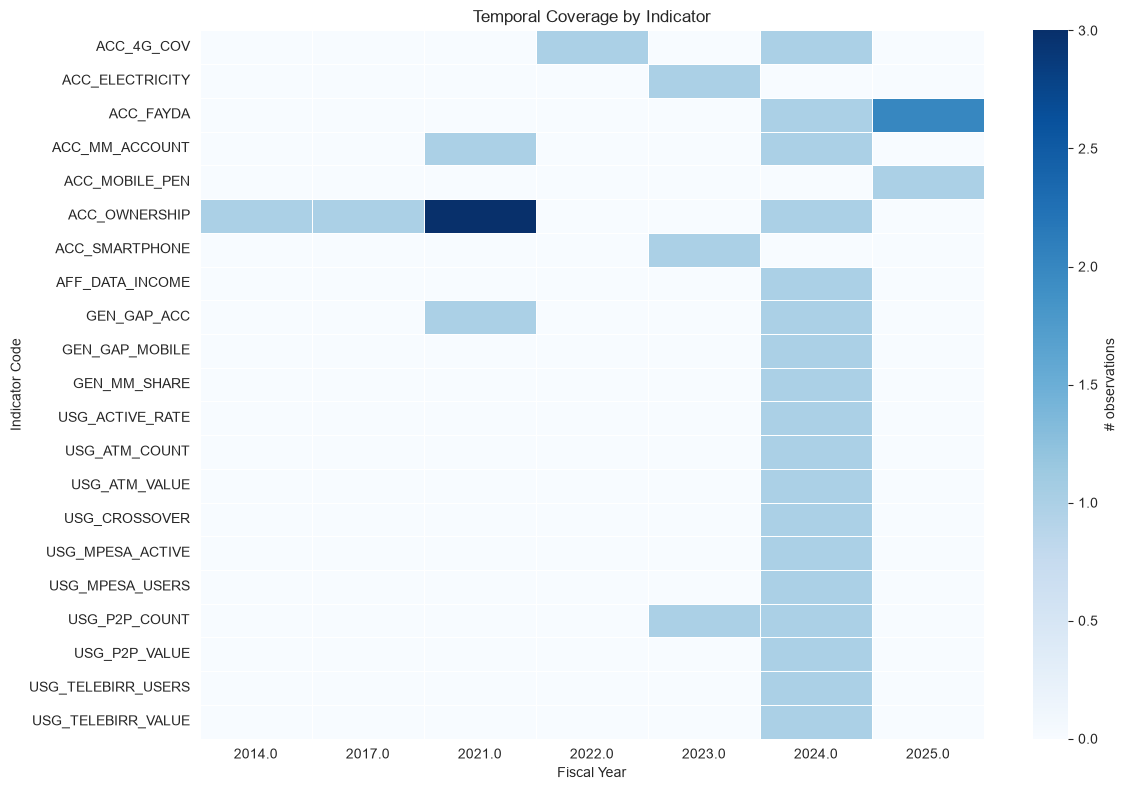

In [2]:
coverage = obs.pivot_table(index="indicator_code", columns="fiscal_year_num",
                            values="record_id", aggfunc="count", fill_value=0)
plt.figure(figsize=(12, 8))
sns.heatmap(coverage, cmap="Blues", cbar_kws={"label": "# observations"}, linewidths=0.5)
plt.title("Temporal Coverage by Indicator")
plt.xlabel("Fiscal Year")
plt.ylabel("Indicator Code")
plt.tight_layout()
plt.show()

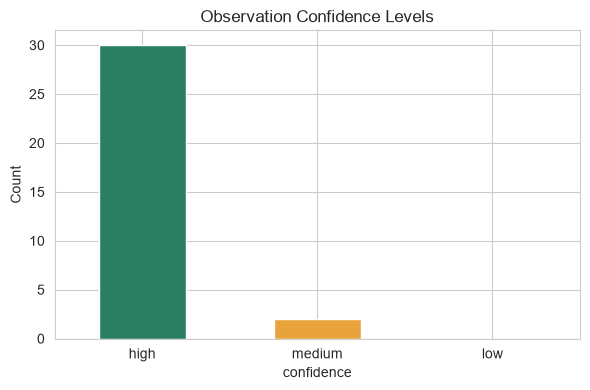

confidence
high      30.0
medium     2.0
low        0.0
Name: count, dtype: float64


In [3]:
conf_order = ["high", "medium", "low"]
conf_counts = obs["confidence"].value_counts().reindex(conf_order).fillna(0)
plt.figure(figsize=(6, 4))
conf_counts.plot(kind="bar", color=["#2a7f62", "#e8a33d", "#c94c4c"])
plt.title("Observation Confidence Levels")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(conf_counts)

In [4]:
sparse = (obs.groupby("indicator_code")
             .agg(indicator=("indicator", "first"), pillar=("pillar", "first"),
                  n_obs=("record_id", "count"))
             .sort_values("n_obs"))
print("Indicators with only 1 observation (sparsest):")
print(sparse[sparse["n_obs"] == 1])

Indicators with only 1 observation (sparsest):
                                            indicator         pillar  n_obs
indicator_code                                                             
ACC_ELECTRICITY               Electricity Access Rate         ACCESS      1
AFF_DATA_INCOME              Data Affordability Index  AFFORDABILITY      1
ACC_SMARTPHONE               Smartphone Adoption Rate         ACCESS      1
ACC_MOBILE_PEN        Mobile Subscription Penetration         ACCESS      1
USG_ATM_COUNT                   ATM Transaction Count          USAGE      1
USG_ACTIVE_RATE            Mobile Money Activity Rate          USAGE      1
GEN_MM_SHARE        Female Mobile Money Account Share         GENDER      1
GEN_GAP_MOBILE                Mobile Phone Gender Gap         GENDER      1
USG_CROSSOVER                 P2P/ATM Crossover Ratio          USAGE      1
USG_ATM_VALUE                   ATM Transaction Value          USAGE      1
USG_MPESA_ACTIVE           M-Pesa 90-Day 

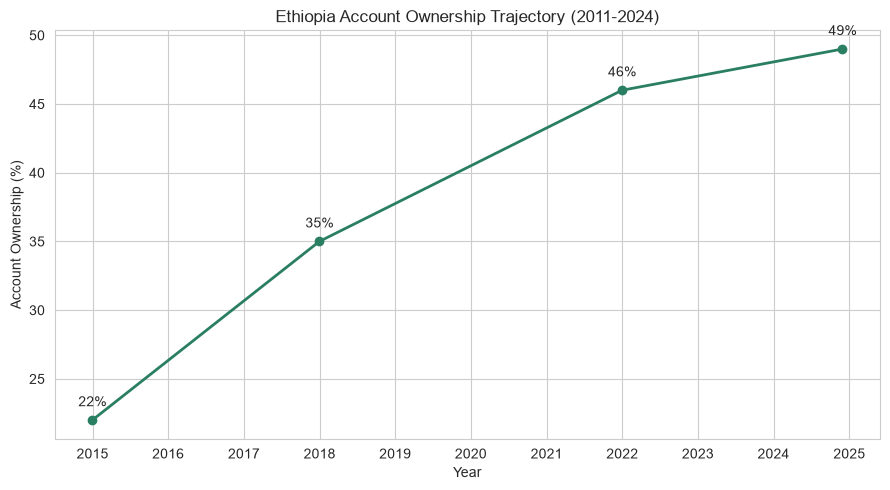

,observation_date,value_numeric,source_name
0,2014-12-31,22.0,Global Findex 2014
1,2017-12-31,35.0,Global Findex 2017
2,2021-12-31,46.0,Global Findex 2021
5,2024-11-29,49.0,Global Findex 2024


In [5]:
access = obs[(obs["indicator_code"] == "ACC_OWNERSHIP") & (obs["gender"] == "all")].sort_values("observation_date")
plt.figure(figsize=(9, 5))
plt.plot(access["observation_date"], access["value_numeric"], marker="o", linewidth=2, color="#2a7f62")
for _, row in access.iterrows():
    plt.annotate(f"{row['value_numeric']:.0f}%", (row["observation_date"], row["value_numeric"]),
                 textcoords="offset points", xytext=(0, 10), ha="center")
plt.title("Ethiopia Account Ownership Trajectory (2011-2024)")
plt.ylabel("Account Ownership (%)")
plt.xlabel("Year")
plt.tight_layout()
plt.show()
access[["observation_date", "value_numeric", "source_name"]]

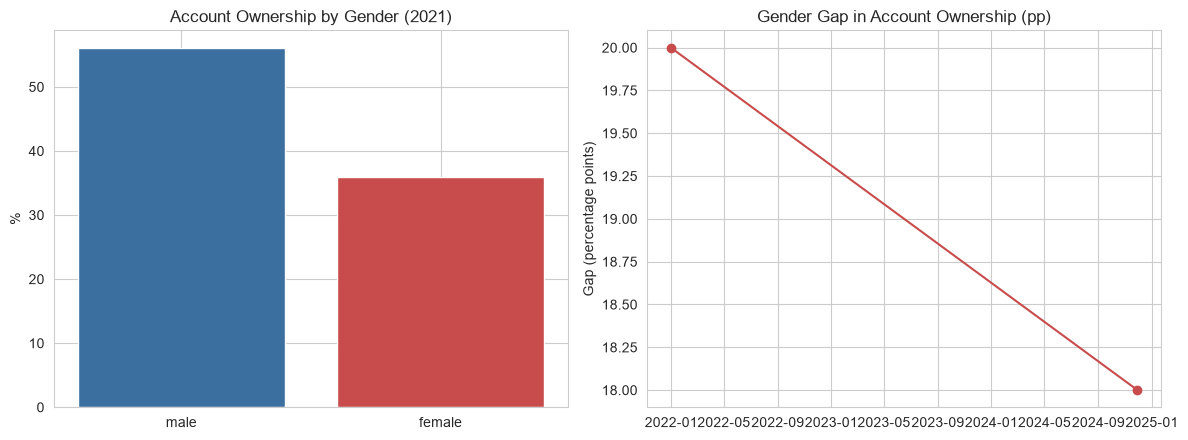

Gender gap narrowed from 20.0 pp (2021) to 18.0 pp (2024, estimated - confidence:medium)


In [6]:
gender_2021 = obs[(obs["indicator_code"] == "ACC_OWNERSHIP") & (obs["gender"].isin(["male", "female"]))]
gap_trend = obs[obs["indicator_code"] == "GEN_GAP_ACC"].sort_values("observation_date")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(gender_2021["gender"], gender_2021["value_numeric"], color=["#3b6fa0", "#c94c4c"])
axes[0].set_title("Account Ownership by Gender (2021)")
axes[0].set_ylabel("%")
axes[1].plot(gap_trend["observation_date"], gap_trend["value_numeric"], marker="o", color="#c94c4c")
axes[1].set_title("Gender Gap in Account Ownership (pp)")
axes[1].set_ylabel("Gap (percentage points)")
plt.tight_layout()
plt.show()
print("Gender gap narrowed from", gap_trend["value_numeric"].iloc[0], "pp (2021) to",
      gap_trend["value_numeric"].iloc[-1], "pp (2024, estimated - confidence:medium)")

In [7]:
urban_rural = obs[obs["location"].isin(["urban", "rural"])]
if urban_rural.empty:
    print("DATA GAP: No urban/rural disaggregated observations exist in the dataset.")
    print("The only urban/rural split available is indirect: electricity access")
    print("(urban 94.7% vs rural 43.6%, World Bank 2023) - a plausible proxy/enabler,")
    print("not a direct account-ownership split. Flagged in data_enrichment_log.md.")
else:
    print(urban_rural)

DATA GAP: No urban/rural disaggregated observations exist in the dataset.
The only urban/rural split available is indirect: electricity access
(urban 94.7% vs rural 43.6%, World Bank 2023) - a plausible proxy/enabler,
not a direct account-ownership split. Flagged in data_enrichment_log.md.


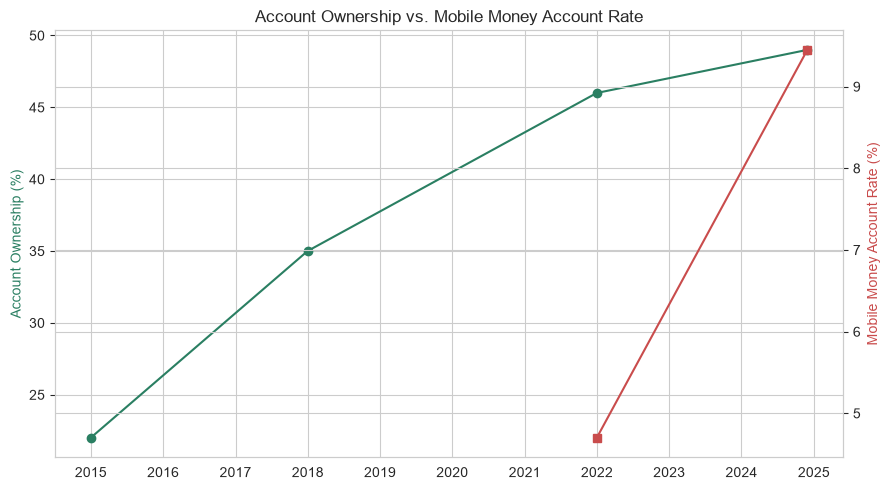

Account ownership grew +3pp (2021-2024) while
Mobile money account rate grew +4.75pp (~doubled) in the same window.
This confirms the brief's framing: massive mobile-money growth did not translate
proportionally into overall account ownership gains - see Sheet D 'Mobile-Money-Only
Users Are Extremely Rare' (~0.5% of adults) as a likely explanation: most new mobile
money accounts in Ethiopia are opened by people who already have a bank account,
so mobile money growth is substituting/complementing existing access more than
creating new first-time account holders.


In [8]:
mm = obs[(obs["indicator_code"] == "ACC_MM_ACCOUNT") & (obs["gender"] == "all")].sort_values("observation_date")

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(access["observation_date"], access["value_numeric"], marker="o", color="#2a7f62", label="Account Ownership (%)")
ax1.set_ylabel("Account Ownership (%)", color="#2a7f62")
ax2 = ax1.twinx()
ax2.plot(mm["observation_date"], mm["value_numeric"], marker="s", color="#c94c4c", label="Mobile Money Account Rate (%)")
ax2.set_ylabel("Mobile Money Account Rate (%)", color="#c94c4c")
plt.title("Account Ownership vs. Mobile Money Account Rate")
fig.tight_layout()
plt.show()

acc_growth_21_24 = access[access["observation_date"].dt.year == 2024]["value_numeric"].iloc[0] - \
                   access[access["observation_date"].dt.year == 2021]["value_numeric"].iloc[0]
mm_growth_21_24 = mm[mm["observation_date"].dt.year == 2024]["value_numeric"].iloc[0] - \
                  mm[mm["observation_date"].dt.year == 2021]["value_numeric"].iloc[0]
print(f"Account ownership grew +{acc_growth_21_24:.0f}pp (2021-2024) while")
print(f"Mobile money account rate grew +{mm_growth_21_24:.2f}pp (~doubled) in the same window.")
print("This confirms the brief's framing: massive mobile-money growth did not translate")
print("proportionally into overall account ownership gains - see Sheet D 'Mobile-Money-Only")
print("Users Are Extremely Rare' (~0.5% of adults) as a likely explanation: most new mobile")
print("money accounts in Ethiopia are opened by people who already have a bank account,")
print("so mobile money growth is substituting/complementing existing access more than")
print("creating new first-time account holders.")

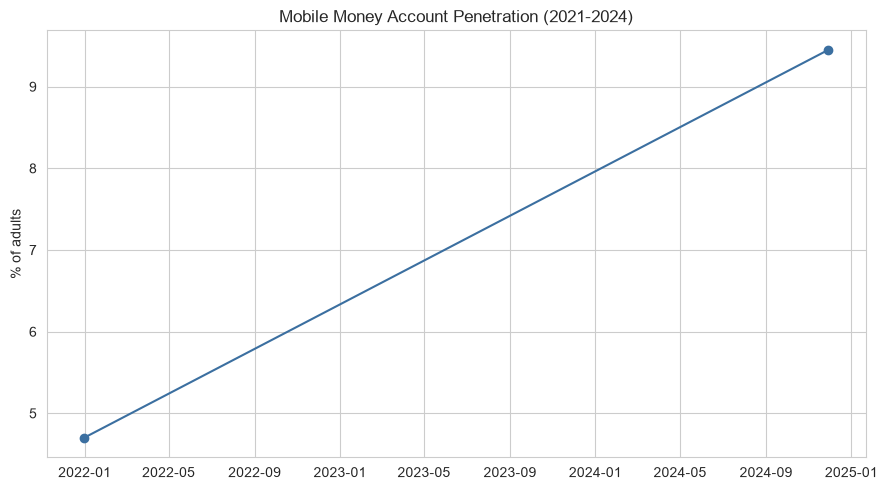

Telebirr registered users: [54840000.] (FY2024/25)
M-Pesa registered users: [10800000.] (2024)


In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(mm["observation_date"], mm["value_numeric"], marker="o", color="#3b6fa0")
ax.set_title("Mobile Money Account Penetration (2021-2024)")
ax.set_ylabel("% of adults")
plt.tight_layout()
plt.show()

telebirr = obs[obs["indicator_code"] == "USG_TELEBIRR_USERS"]
mpesa = obs[obs["indicator_code"] == "USG_MPESA_USERS"]
print("Telebirr registered users:", telebirr["value_numeric"].values, "(FY2024/25)")
print("M-Pesa registered users:", mpesa["value_numeric"].values, "(2024)")

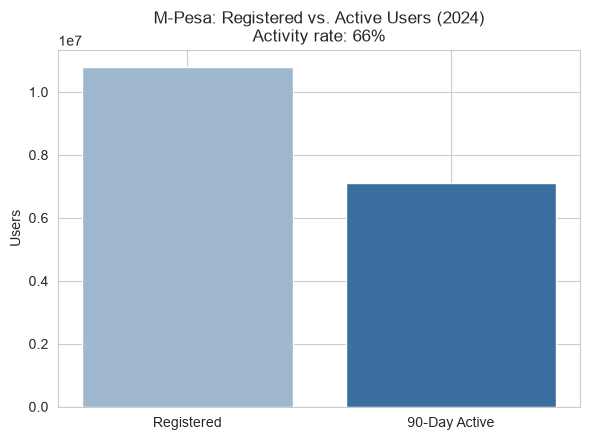

M-Pesa: 10.8M registered -> 7.1M active (66%).
NOTE: Telebirr has no equivalent active-user observation in the dataset - a data gap.
Given Telebirr's much larger scale (54.8M registered), its true active-user rate is
unknown and is a priority addition for future data collection.


In [10]:
mpesa_active = obs[obs["indicator_code"] == "USG_MPESA_ACTIVE"]["value_numeric"].iloc[0]
mpesa_reg = mpesa["value_numeric"].iloc[0]
active_rate = obs[obs["indicator_code"] == "USG_ACTIVE_RATE"]["value_numeric"].iloc[0]

plt.figure(figsize=(6, 4.5))
plt.bar(["Registered", "90-Day Active"], [mpesa_reg, mpesa_active], color=["#9fb8d0", "#3b6fa0"])
plt.title(f"M-Pesa: Registered vs. Active Users (2024)\nActivity rate: {active_rate:.0f}%")
plt.ylabel("Users")
plt.tight_layout()
plt.show()
print(f"M-Pesa: {mpesa_reg/1e6:.1f}M registered -> {mpesa_active/1e6:.1f}M active ({active_rate:.0f}%).")
print("NOTE: Telebirr has no equivalent active-user observation in the dataset - a data gap.")
print("Given Telebirr's much larger scale (54.8M registered), its true active-user rate is")
print("unknown and is a priority addition for future data collection.")

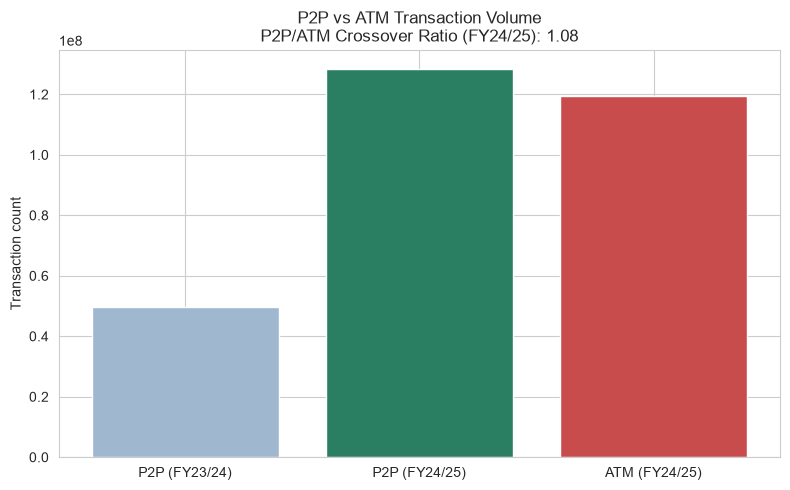

P2P transactions overtook ATM transactions for the first time in FY2024/25 (EVT_0006).
Per Sheet D 'P2P Dominance in Ethiopia': unlike global norms, P2P rails in Ethiopia are
used for actual goods/services payment, not just transfers - so this crossover likely
understates real digital *commerce* usage if benchmarked against global P2P-vs-merchant frameworks.


In [11]:
p2p_count = obs[obs["indicator_code"] == "USG_P2P_COUNT"].sort_values("observation_date")
atm_count = obs[obs["indicator_code"] == "USG_ATM_COUNT"]
crossover = obs[obs["indicator_code"] == "USG_CROSSOVER"]["value_numeric"].iloc[0]

plt.figure(figsize=(8, 5))
plt.bar(["P2P (FY23/24)", "P2P (FY24/25)", "ATM (FY24/25)"],
        [p2p_count["value_numeric"].iloc[0], p2p_count["value_numeric"].iloc[1], atm_count["value_numeric"].iloc[0]],
        color=["#9fb8d0", "#2a7f62", "#c94c4c"])
plt.title(f"P2P vs ATM Transaction Volume\nP2P/ATM Crossover Ratio (FY24/25): {crossover}")
plt.ylabel("Transaction count")
plt.tight_layout()
plt.show()
print("P2P transactions overtook ATM transactions for the first time in FY2024/25 (EVT_0006).")
print("Per Sheet D 'P2P Dominance in Ethiopia': unlike global norms, P2P rails in Ethiopia are")
print("used for actual goods/services payment, not just transfers - so this crossover likely")
print("understates real digital *commerce* usage if benchmarked against global P2P-vs-merchant frameworks.")

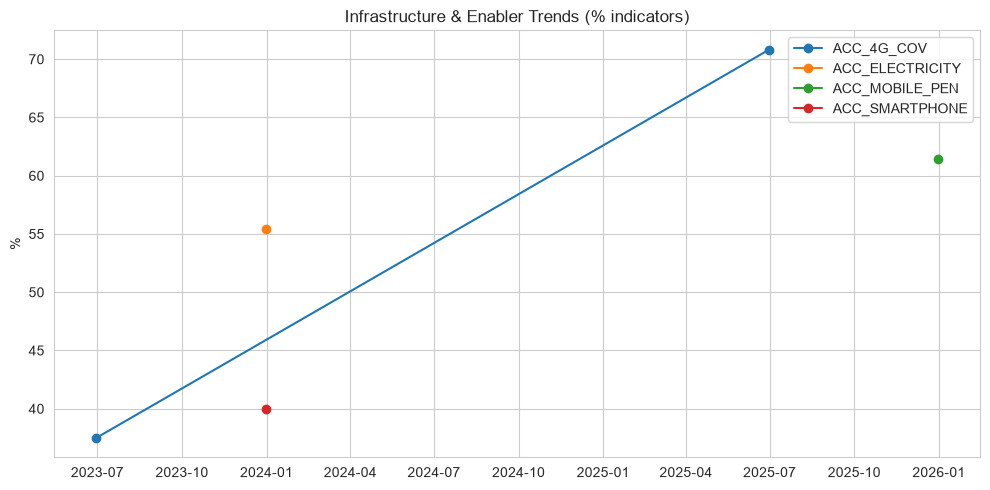

,indicator_code,indicator,observation_date,value_numeric,unit
8,ACC_4G_COV,4G Population Coverage,2023-06-30,37.5,%
9,ACC_4G_COV,4G Population Coverage,2025-06-30,70.8,%
58,ACC_ELECTRICITY,Electricity Access Rate,2023-12-31,55.4,%
11,ACC_FAYDA,Fayda Digital ID Enrollment,2024-08-15,8000000.0,people
12,ACC_FAYDA,Fayda Digital ID Enrollment,2025-02-28,12000000.0,people
13,ACC_FAYDA,Fayda Digital ID Enrollment,2025-05-15,15000000.0,people
10,ACC_MOBILE_PEN,Mobile Subscription Penetration,2025-12-31,61.4,%
57,ACC_SMARTPHONE,Smartphone Adoption Rate,2023-12-31,40.0,%


In [12]:
enablers = obs[obs["indicator_code"].isin(
    ["ACC_4G_COV", "ACC_MOBILE_PEN", "ACC_SMARTPHONE", "ACC_ELECTRICITY", "ACC_FAYDA"]
)].sort_values(["indicator_code", "observation_date"])

fig, ax = plt.subplots(figsize=(10, 5))
for code, grp in enablers.groupby("indicator_code"):
    if grp["value_type"].iloc[0] == "percentage":
        ax.plot(grp["observation_date"], grp["value_numeric"], marker="o", label=code)
ax.set_title("Infrastructure & Enabler Trends (% indicators)")
ax.set_ylabel("%")
ax.legend()
plt.tight_layout()
plt.show()
enablers[["indicator_code", "indicator", "observation_date", "value_numeric", "unit"]]

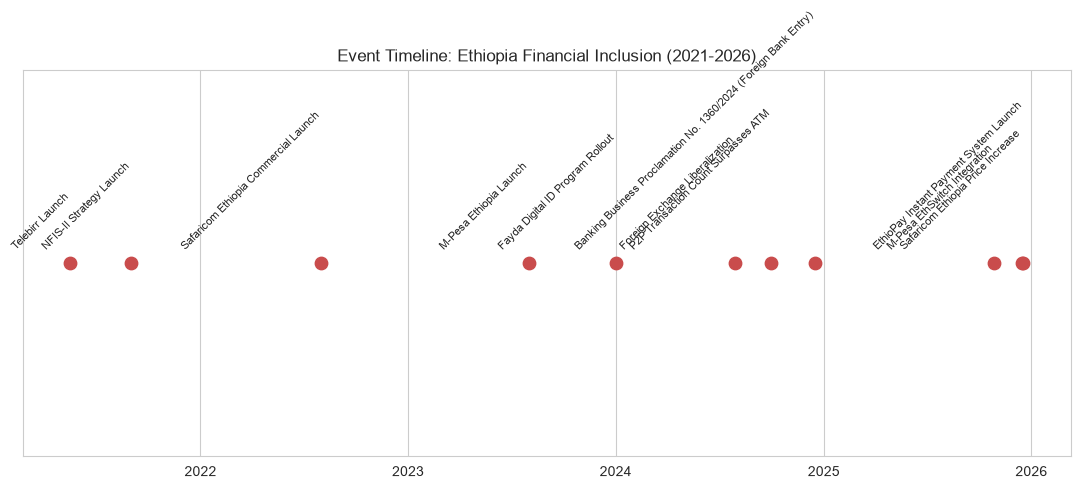

In [13]:
events_sorted = events.dropna(subset=["observation_date"]).sort_values("observation_date")
fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(events_sorted["observation_date"], [1] * len(events_sorted), s=80, color="#c94c4c", zorder=3)
for _, row in events_sorted.iterrows():
    ax.annotate(row["indicator"], (row["observation_date"], 1), rotation=45,
                ha="right", va="bottom", fontsize=8, xytext=(0, 8), textcoords="offset points")
ax.get_yaxis().set_visible(False)
ax.set_title("Event Timeline: Ethiopia Financial Inclusion (2021-2026)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

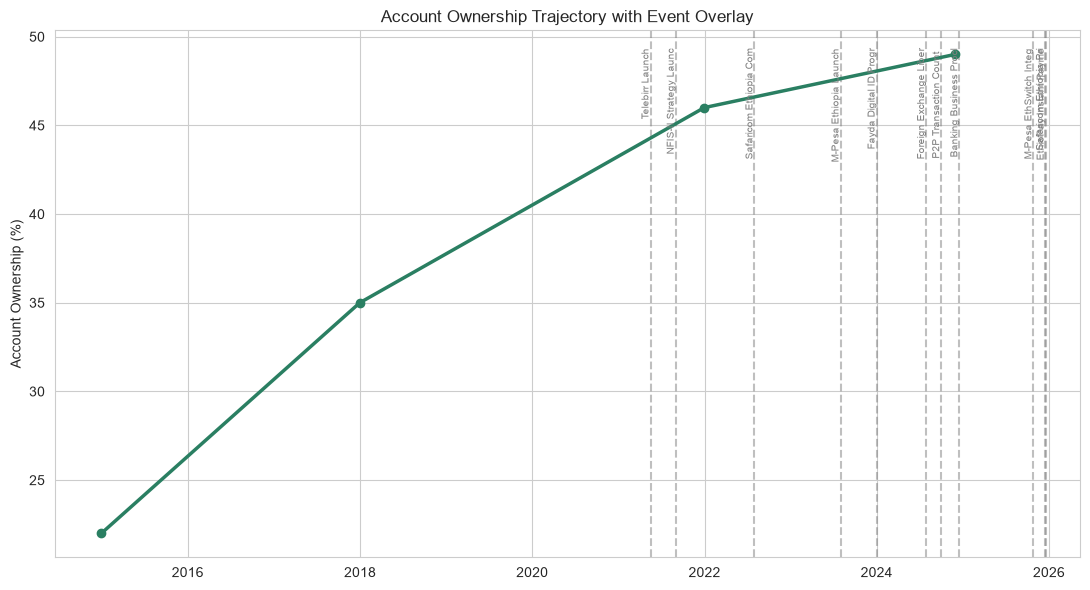

Telebirr launched May 2021 - the only Findex points bracketing it are 2021 (46%) and
2024 (49%), so we cannot isolate a same-year acceleration from Findex alone; EthSwitch
operator data (P2P +158% YoY in FY24/25) shows Telebirr-era digital *usage* accelerated
sharply even though *ownership* barely moved - reinforcing the ownership-vs-usage gap.


In [14]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(access["observation_date"], access["value_numeric"], marker="o", linewidth=2.5, color="#2a7f62", zorder=3)
for _, row in events_sorted.iterrows():
    ax.axvline(row["observation_date"], color="grey", linestyle="--", alpha=0.5)
    ax.text(row["observation_date"], ax.get_ylim()[1] * 0.98, row["indicator"][:22],
            rotation=90, fontsize=7, va="top", ha="right", color="grey")
ax.set_title("Account Ownership Trajectory with Event Overlay")
ax.set_ylabel("Account Ownership (%)")
plt.tight_layout()
plt.show()
print("Telebirr launched May 2021 - the only Findex points bracketing it are 2021 (46%) and")
print("2024 (49%), so we cannot isolate a same-year acceleration from Findex alone; EthSwitch")
print("operator data (P2P +158% YoY in FY24/25) shows Telebirr-era digital *usage* accelerated")
print("sharply even though *ownership* barely moved - reinforcing the ownership-vs-usage gap.")

Indicator values by fiscal year (wide format):
indicator_code   ACC_4G_COV   ACC_FAYDA  ACC_MM_ACCOUNT  ACC_MOBILE_PEN  ACC_OWNERSHIP
fiscal_year_num                                                                       
2014.0                  NaN         NaN             NaN             NaN           22.0
2017.0                  NaN         NaN             NaN             NaN           35.0
2021.0                  NaN         NaN            4.70             NaN           46.0
2022.0                 37.5         NaN             NaN             NaN            NaN
2024.0                 70.8   8000000.0            9.45             NaN           49.0
2025.0                  NaN  13500000.0             NaN            61.4            NaN

n = 0 fully-overlapping year(s) - TOO FEW to compute a statistically meaningful correlation matrix.
Treat any correlation below as illustrative only, not evidence of causation or even association.


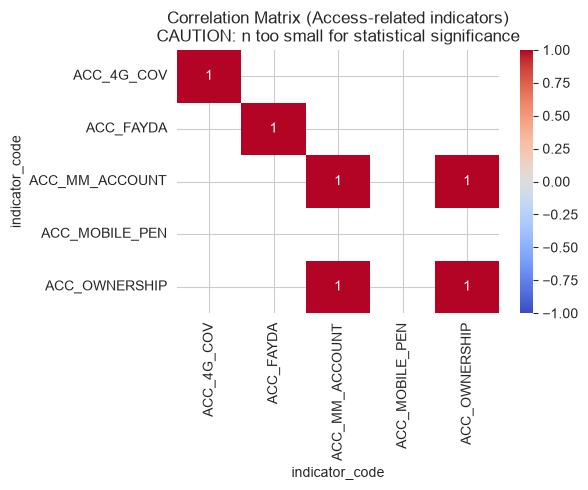

In [15]:
key_codes = ["ACC_OWNERSHIP", "ACC_MM_ACCOUNT", "ACC_4G_COV", "ACC_MOBILE_PEN", "ACC_FAYDA"]
pivot = (obs[obs["indicator_code"].isin(key_codes) & (obs["gender"] == "all")]
         .pivot_table(index="fiscal_year_num", columns="indicator_code", values="value_numeric", aggfunc="mean"))
print("Indicator values by fiscal year (wide format):")
print(pivot)
print(f"\nn = {pivot.dropna().shape[0]} fully-overlapping year(s) -", end=" ")
if pivot.dropna().shape[0] < 4:
    print("TOO FEW to compute a statistically meaningful correlation matrix.")
    print("Treat any correlation below as illustrative only, not evidence of causation or even association.")
corr = pivot.corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix (Access-related indicators)\nCAUTION: n too small for statistical significance")
plt.tight_layout()
plt.show()

In [16]:
links_by_pillar = links.groupby("pillar").agg(
    n_links=("record_id", "count"),
    avg_impact_estimate=("impact_estimate", lambda x: pd.to_numeric(x, errors="coerce").mean())
).sort_values("n_links", ascending=False)
print(links_by_pillar)
print("\nUSAGE has the most modeled impact_links, consistent with the observation that most")
print("cataloged events (product launches, interoperability, instant payments) are")
print("usage/transaction-side interventions rather than account-opening/access-side ones -")
print("which itself may help explain why Access has grown more slowly than Usage indicators.")

               n_links  avg_impact_estimate
pillar                                     
USAGE                7            13.200000
ACCESS               5             9.600000
AFFORDABILITY        3             6.666667
GENDER               1            -5.000000

USAGE has the most modeled impact_links, consistent with the observation that most
cataloged events (product launches, interoperability, instant payments) are
usage/transaction-side interventions rather than account-opening/access-side ones -
which itself may help explain why Access has grown more slowly than Usage indicators.


## Key Insights

1. **Mobile money growth ≠ account ownership growth.** Mobile money account rate roughly
   doubled (4.7%→9.5%, 2021-2024) while overall account ownership grew only +3pp (46%→49%).
   Only ~0.5% of Ethiopian adults are mobile-money-only (Sheet D), meaning most new mobile
   money accounts layer onto existing bank access rather than creating new account holders.

2. **The gender gap is large and only slowly narrowing.** Male ownership (56%) exceeded
   female (36%) by 20pp in 2021; estimated ~18pp in 2024 (confidence: medium) — a 2pp
   narrowing over 3 years despite Fayda digital ID rollout, which literature (India Aadhaar)
   suggested could help disproportionately-unbanked women.

3. **Usage indicators are accelerating far faster than Access indicators.** P2P transactions
   grew +158% YoY (FY24/25) and overtook ATM transactions for the first time — but this
   usage boom is concentrated in already-included users, not translating into new account
   ownership at a comparable pace.

4. **Registered-vs-active gaps are a major hidden data problem.** M-Pesa's true active rate
   is only 66% (7.1M of 10.8M registered) — and Telebirr, with 5x more registered users
   (54.8M), has no equivalent active-user figure in the dataset at all, so its real reach is
   unknown.

5. **Infrastructure enablers (4G coverage, electricity access) roughly doubled/rose
   steadily over the same period Access stagnated**, suggesting infrastructure alone is not
   the binding constraint on Access — the barrier is more likely elsewhere (e.g. KYC/ID
   requirements, trust, or the "bank-only vs mobile-only" dynamic in Sheet D).

**Data gaps limiting this analysis:** no urban/rural account-ownership split; no
Telebirr active-user data; only 5 Findex survey points across 13 years (too sparse for
rigorous correlation/causal analysis — flagged directly in Cell 17).

**Hypotheses for Task 3 impact modeling:** (a) Fayda ID rollout may show a lagged
(24mo+) effect on Access, not immediate; (b) interoperability/instant-payment events
(M-Pesa↔EthSwitch, EthioPay) primarily affect Usage, not Access; (c) foreign bank entry
(EVT_0011) is a medium-term Access lever worth testing against Nigeria's liberalization
comparator.